In [2]:
!pip install kagglehub --quiet
import kagglehub
path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Путь:", path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Путь: /kaggle/input/lfw-dataset


In [3]:
# ============================================================
#  ЕДИНАЯ ИНИЦИАЛИЗАЦИЯ: импорты, модели, пути, функции
# ============================================================

# ---------- Стандартные импорты ----------
import os
import sys
import time
import pickle
import shutil
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# ---------- PyTorch / FaceNet ----------
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
import torchvision.transforms as T

# ---------- OpenCV ----------
import cv2

# ---------- dlib ----------
try:
    import dlib
    DLIB_OK = True
except ImportError:
    DLIB_OK = False
    print("⚠️ dlib не установлен — архитектура №3 будет недоступна")

# ---------- DeepFace ----------
try:
    from deepface import DeepFace
    DEEPFACE_OK = True
except ImportError:
    DEEPFACE_OK = False
    print("⚠️ deepface не установлен — архитектура №4 будет недоступна")

# ---------- InsightFace ----------
try:
    import insightface
    from insightface.app import FaceAnalysis
    INSIGHT_OK = True
except Exception as e:
    INSIGHT_OK = False
    print(f"⚠️ insightface не работает: {e}")

# ============================================================
#  ПУТИ
# ============================================================
PROJECT_DIR = "/content/drive/MyDrive/face_project"
GALLERY_DIR = f"{PROJECT_DIR}/face_data/gallery"
PROBE_DIR = f"{PROJECT_DIR}/face_data/probe"
BENCH_DIR = f"{PROJECT_DIR}/benchmarks"
DLIB_MODELS_DIR = f"{PROJECT_DIR}/dlib_models"

for d in [PROJECT_DIR, GALLERY_DIR, PROBE_DIR, BENCH_DIR, DLIB_MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

# Путь к LFW — kagglehub кладёт в свой кэш
LFW_ROOT = None
for root in ["/root/.cache/kagglehub", "/content/.cache/kagglehub"]:
    if os.path.exists(root):
        for dirpath, dirnames, _ in os.walk(root):
            if "lfw-deepfunneled" in dirnames:
                LFW_ROOT = os.path.join(dirpath, "lfw-deepfunneled")
                break
    if LFW_ROOT:
        break

if LFW_ROOT and os.path.exists(os.path.join(LFW_ROOT, "lfw-deepfunneled")):
    LFW_ROOT = os.path.join(LFW_ROOT, "lfw-deepfunneled")

print("PROJECT_DIR:", PROJECT_DIR)
print("LFW_ROOT:", LFW_ROOT)

# ============================================================
#  СПИСКИ ЛЮДЕЙ
# ============================================================
TARGET_PEOPLE = ["George_W_Bush", "Colin_Powell", "Tony_Blair", "Serena_Williams", "Laura_Bush"]

EASY_UNKNOWN = ["Ariel_Sharon", "Hugo_Chavez", "Junichiro_Koizumi", "Jean_Chretien", "Vladimir_Putin"]

HARD_UNKNOWN = ["Venus_Williams", "Oprah_Winfrey", "Jennifer_Aniston", "Nicole_Kidman",
                "Jose_Maria_Aznar", "Silvio_Berlusconi", "Tiger_Woods", "Kofi_Annan",
                "Dick_Cheney", "John_Kerry"]

ALL_UNKNOWN = EASY_UNKNOWN + HARD_UNKNOWN

# ============================================================
#  УСТРОЙСТВО
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============================================================
#  МОДЕЛИ: FaceNet (MTCNN + InceptionResnetV1)
# ============================================================
mtcnn = MTCNN(keep_all=True, device=device)
facenet_model = InceptionResnetV1(pretrained="vggface2").eval().to(device)

facenet_transform = T.Compose([
    T.Resize((160, 160)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ============================================================
#  МОДЕЛИ: dlib
# ============================================================
if DLIB_OK:
    sp_path = f"{DLIB_MODELS_DIR}/shape_predictor_68_face_landmarks.dat"
    rec_path = f"{DLIB_MODELS_DIR}/dlib_face_recognition_resnet_model_v1.dat"

    if not os.path.exists(sp_path) or not os.path.exists(rec_path):
        import urllib.request, bz2
        def dl(url, out):
            if os.path.exists(out):
                return
            bz = out + ".bz2"
            print(f"Скачиваем {url}...")
            urllib.request.urlretrieve(url, bz)
            with bz2.open(bz, "rb") as fi, open(out, "wb") as fo:
                shutil.copyfileobj(fi, fo)
            os.remove(bz)

        dl("http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2", sp_path)
        dl("http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2", rec_path)

    dlib_detector = dlib.get_frontal_face_detector()
    dlib_sp = dlib.shape_predictor(sp_path)
    dlib_facerec = dlib.face_recognition_model_v1(rec_path)
    print("dlib модели загружены")
else:
    dlib_detector = dlib_sp = dlib_facerec = None

# ============================================================
#  МОДЕЛИ: Haar Cascade
# ============================================================
haar = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# ============================================================
#  МОДЕЛИ: InsightFace (SCRFD + ArcFace)
# ============================================================
if INSIGHT_OK:
    try:
        insight_app = FaceAnalysis(
            name="buffalo_sc",
            providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
        )
        insight_app.prepare(ctx_id=0, det_size=(640, 640))
        print("InsightFace модели загружены")
    except Exception as e:
        INSIGHT_OK = False
        insight_app = None
        print(f"⚠️ InsightFace не инициализировался: {e}")
else:
    insight_app = None

# ============================================================
#  ОБЩИЕ МЕТРИКИ
# ============================================================
def cosine_similarity(a, b):
    a = a / (np.linalg.norm(a) + 1e-12)
    b = b / (np.linalg.norm(b) + 1e-12)
    return float(np.dot(a, b))

def euclidean(a, b):
    return float(np.linalg.norm(a - b))

def dist_to_sim(d):
    return 1.0 / (1.0 + d)

# ============================================================
#  ФУНКЦИИ ДЕТЕКЦИИ
# ============================================================
def detect_face(img_pil, min_prob=0.95, min_size=40):
    """MTCNN с фильтрацией: возвращает самый крупный бокс или None."""
    boxes, probs = mtcnn.detect(img_pil)
    if boxes is None:
        return None, None

    W, H = img_pil.size
    candidates = []
    for box, prob in zip(boxes, probs):
        x1, y1, x2, y2 = box
        if prob < min_prob:
            continue
        if x1 < 0 or y1 < 0 or x2 > W or y2 > H:
            continue
        if (x2 - x1) < min_size or (y2 - y1) < min_size:
            continue
        candidates.append(((x2 - x1) * (y2 - y1), box, prob))

    if not candidates:
        return None, None
    candidates.sort(key=lambda c: c[0], reverse=True)
    return candidates[0][1], candidates[0][2]

def detect_haar(img_pil):
    """Haar Cascade: возвращает (x1, y1, x2, y2) самого крупного лица."""
    img_bgr = cv2.cvtColor(np.array(img_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = haar.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
    if len(faces) == 0:
        return None
    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
    x, y, w, h = faces[0]
    return (x, y, x + w, y + h)

def detect_dlib(img_pil, upsample=1):
    """dlib HOG: возвращает (rect, shape) или (None, None)."""
    if not DLIB_OK:
        return None, None
    img_np = np.array(img_pil.convert("RGB"))
    rects = dlib_detector(img_np, upsample)
    if len(rects) == 0:
        return None, None
    rects = sorted(rects, key=lambda r: r.width() * r.height(), reverse=True)
    rect = rects[0]
    shape = dlib_sp(img_np, rect)
    return rect, shape

# ============================================================
#  ФУНКЦИИ ЭМБЕДДИНГОВ
# ============================================================
def get_embedding_facenet(img_pil):
    """FaceNet: 512-мерный эмбеддинг или None."""
    box, _ = detect_face(img_pil)
    if box is None:
        return None
    x1, y1, x2, y2 = box
    pad = 0.1 * max(x2 - x1, y2 - y1)
    x1 = max(0, int(x1 - pad))
    y1 = max(0, int(y1 - pad))
    x2 = min(img_pil.size[0], int(x2 + pad))
    y2 = min(img_pil.size[1], int(y2 + pad))
    face = img_pil.crop((x1, y1, x2, y2))
    tensor = facenet_transform(face).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = facenet_model(tensor)
    return emb.cpu().numpy().flatten()

def get_embedding_dlib(img_pil):
    """dlib ResNet-29: 128-мерный эмбеддинг или None."""
    if not DLIB_OK:
        return None
    img_np = np.array(img_pil.convert("RGB"))
    rects = dlib_detector(img_np, 1)
    if len(rects) == 0:
        return None
    rects = sorted(rects, key=lambda r: r.width() * r.height(), reverse=True)
    shape = dlib_sp(img_np, rects[0])
    emb = dlib_facerec.compute_face_descriptor(img_np, shape)
    return np.array(emb)

def get_embedding_arcface(img_pil, detector="retinaface", model="ArcFace"):
    """RetinaFace + ArcFace через deepface: 512-мерный эмбеддинг или None."""
    if not DEEPFACE_OK:
        return None
    img_bgr = np.array(img_pil.convert("RGB"))[:, :, ::-1].copy()
    try:
        results = DeepFace.represent(
            img_path=img_bgr,
            model_name=model,
            detector_backend=detector,
            enforce_detection=True,
        )
    except ValueError:
        return None
    if not results:
        return None
    results = sorted(results, key=lambda r: r["facial_area"]["w"] * r["facial_area"]["h"], reverse=True)
    return np.array(results[0]["embedding"])

def get_embedding_insight(img_pil):
    """SCRFD + ArcFace (insightface buffalo_sc): 512-мерный нормированный эмбеддинг или None."""
    if not INSIGHT_OK or insight_app is None:
        return None
    img_bgr = np.array(img_pil.convert("RGB"))[:, :, ::-1].copy()
    faces = insight_app.get(img_bgr)
    if not faces:
        return None
    faces = sorted(faces, key=lambda f: (f.bbox[2]-f.bbox[0]) * (f.bbox[3]-f.bbox[1]), reverse=True)
    return faces[0].normed_embedding

# ============================================================
#  ФУНКЦИИ ИДЕНТИФИКАЦИИ
# ============================================================
def identify_cosine(emb, gallery_emb, threshold=0.6):
    """Для FaceNet и ArcFace: max по косинусу."""
    all_sims = {}
    for person, embs in gallery_emb.items():
        sims = [cosine_similarity(emb, g) for g in embs]
        all_sims[person] = max(sims)
    best_person = max(all_sims, key=all_sims.get)
    best_sim = all_sims[best_person]
    if best_sim < threshold:
        return "unknown", best_sim, all_sims
    return best_person, best_sim, all_sims

def identify_l2(emb, gallery_emb, threshold_dist=0.6):
    """Для dlib: min по L2, порог по расстоянию."""
    min_dists = {}
    for person, embs in gallery_emb.items():
        dists = [euclidean(emb, g) for g in embs]
        min_dists[person] = min(dists)
    best_person = min(min_dists, key=min_dists.get)
    best_dist = min_dists[best_person]
    if best_dist > threshold_dist:
        return "unknown", best_dist, min_dists
    return best_person, best_dist, min_dists

# ============================================================
#  ПРОВЕРКА
# ============================================================
print("\n" + "=" * 60)
print("ИНИЦИАЛИЗАЦИЯ ЗАВЕРШЕНА")
print("=" * 60)
print(f"CUDA:        {torch.cuda.is_available()}")
print(f"FaceNet:     ✅")
print(f"MTCNN:       ✅")
print(f"Haar+LBPH:   ✅ (cv2.face: {hasattr(cv2, 'face')})")
print(f"dlib:        {'✅' if DLIB_OK else '❌'}")
print(f"deepface:    {'✅' if DEEPFACE_OK else '❌'}")
print(f"insightface: {'✅' if INSIGHT_OK else '❌'}")
print(f"LFW_ROOT:    {LFW_ROOT}")
print(f"Gallery:     {GALLERY_DIR}")
print(f"Probe:       {PROBE_DIR}")
print("=" * 60)

26-09-21 13:57:19 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.

PROJECT_DIR: /content/drive/MyDrive/face_project
LFW_ROOT: None
Device: cuda
GPU: Tesla T4
dlib модели загружены
download_path: /root/.insightface/models/buffalo_sc


100%|██████████| 14619/14619 [00:00<00:00, 41338.03KB/s]

InsightFace модели загружены

ИНИЦИАЛИЗАЦИЯ ЗАВЕРШЕНА
CUDA:        True
FaceNet:     ✅
MTCNN:       ✅
Haar+LBPH:   ✅ (cv2.face: True)
dlib:        ✅
deepface:    ✅
insightface: ✅
LFW_ROOT:    None
Gallery:     /content/drive/MyDrive/face_project/face_data/gallery
Probe:       /content/drive/MyDrive/face_project/face_data/probe


In [4]:
import os

PROJECT_DIR = "/content/drive/MyDrive/face_project"

for sub in ["face_data/gallery", "face_data/probe"]:
    path = f"{PROJECT_DIR}/{sub}"
    if os.path.exists(path):
        people = sorted(os.listdir(path))
        print(f"✅ {sub}:")
        for p in people:
            n = len(os.listdir(os.path.join(path, p)))
            print(f"   {p}: {n} фото")
    else:
        print(f"❌ {sub} отсутствует")
    print()

✅ face_data/gallery:
   Colin_Powell: 15 фото
   George_W_Bush: 15 фото
   Laura_Bush: 15 фото
   Serena_Williams: 15 фото
   Tony_Blair: 15 фото

✅ face_data/probe:
   Colin_Powell: 221 фото
   George_W_Bush: 515 фото
   Laura_Bush: 26 фото
   Serena_Williams: 37 фото
   Tony_Blair: 129 фото



In [5]:
!pip install kagglehub --quiet

import kagglehub
import shutil

path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Скачано в:", path)

# Находим папку с deepfunneled изображениями
lfw_src = None
for root, dirs, _ in os.walk(path):
    if "lfw-deepfunneled" in dirs:
        lfw_src = os.path.join(root, "lfw-deepfunneled")
        break

if lfw_src and os.path.exists(os.path.join(lfw_src, "lfw-deepfunneled")):
    lfw_src = os.path.join(lfw_src, "lfw-deepfunneled")

print("Источник:", lfw_src)
print("Людей в источнике:", len(os.listdir(lfw_src)))

# Копируем на Drive
LFW_DRIVE = f"{PROJECT_DIR}/lfw-deepfunneled"
if not os.path.exists(LFW_DRIVE):
    print("Копируем на Drive (1-2 минуты)...")
    shutil.copytree(lfw_src, LFW_DRIVE)
    print("Готово")
else:
    print("Уже на Drive")

print("LFW на Drive:", LFW_DRIVE)
print("Людей:", len(os.listdir(LFW_DRIVE)))

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Скачано в: /kaggle/input/lfw-dataset
Источник: /kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled
Людей в источнике: 5749
Копируем на Drive (1-2 минуты)...
Готово
LFW на Drive: /content/drive/MyDrive/face_project/lfw-deepfunneled
Людей: 5749


In [6]:
LFW_ROOT = "/content/drive/MyDrive/face_project/lfw-deepfunneled"

# Проверим наличие всех нужных людей
needed_people = [
    "George_W_Bush", "Colin_Powell", "Tony_Blair", "Serena_Williams", "Laura_Bush",
    "Ariel_Sharon", "Hugo_Chavez", "Junichiro_Koizumi", "Jean_Chretien", "Vladimir_Putin",
    "Venus_Williams", "Oprah_Winfrey", "Jennifer_Aniston", "Nicole_Kidman",
    "Jose_Maria_Aznar", "Silvio_Berlusconi", "Tiger_Woods", "Kofi_Annan",
    "Dick_Cheney", "John_Kerry",
]

for p in needed_people:
    full = os.path.join(LFW_ROOT, p)
    if os.path.isdir(full):
        print(f"✅ {p}: {len(os.listdir(full))} фото")
    else:
        print(f"❌ {p}: не найден")

✅ George_W_Bush: 530 фото
✅ Colin_Powell: 236 фото
✅ Tony_Blair: 144 фото
✅ Serena_Williams: 52 фото
✅ Laura_Bush: 41 фото
✅ Ariel_Sharon: 77 фото
✅ Hugo_Chavez: 71 фото
✅ Junichiro_Koizumi: 60 фото
✅ Jean_Chretien: 55 фото
✅ Vladimir_Putin: 49 фото
✅ Venus_Williams: 17 фото
✅ Oprah_Winfrey: 4 фото
✅ Jennifer_Aniston: 21 фото
✅ Nicole_Kidman: 19 фото
✅ Jose_Maria_Aznar: 23 фото
✅ Silvio_Berlusconi: 33 фото
✅ Tiger_Woods: 23 фото
✅ Kofi_Annan: 32 фото
✅ Dick_Cheney: 14 фото
✅ John_Kerry: 17 фото


In [7]:
LFW_ROOT = "/content/drive/MyDrive/face_project/lfw-deepfunneled"
GALLERY_DIR = "/content/drive/MyDrive/face_project/face_data/gallery"
PROBE_DIR = "/content/drive/MyDrive/face_project/face_data/probe"
BENCH_DIR = "/content/drive/MyDrive/face_project/benchmarks"
print("LFW_ROOT обновлён:", LFW_ROOT)

LFW_ROOT обновлён: /content/drive/MyDrive/face_project/lfw-deepfunneled


АРХИТЕКТУРА №1: MTCNN + InceptionResnetV1 (VGGFace2)

[1/6] Считаем эмбеддинги галереи...


  George_W_Bush: 15 эмбеддингов


  Colin_Powell: 15 эмбеддингов


  Tony_Blair: 15 эмбеддингов


  Serena_Williams: 15 эмбеддингов


  Laura_Bush: 15 эмбеддингов
  Галерея посчитана за 6.2 сек

[2/6] Прогон probe (свои)...


  Closed-set accuracy: 928/928 = 1.0000
  Не найдено лиц: 0
  Время: 53.7 сек

[3/6] Прогон unknown...


  Всего unknown: 271
  Время: 15.6 сек

[4/6] Считаем метрики...
  EER: 0.0115
  Порог: 0.7389
  AUC: 0.8704

  Ложно принято: 16/271
    Venus_Williams → Serena_Williams: 16

[5/6] Сохранено: /content/drive/MyDrive/face_project/benchmarks/v1_facenet.pkl


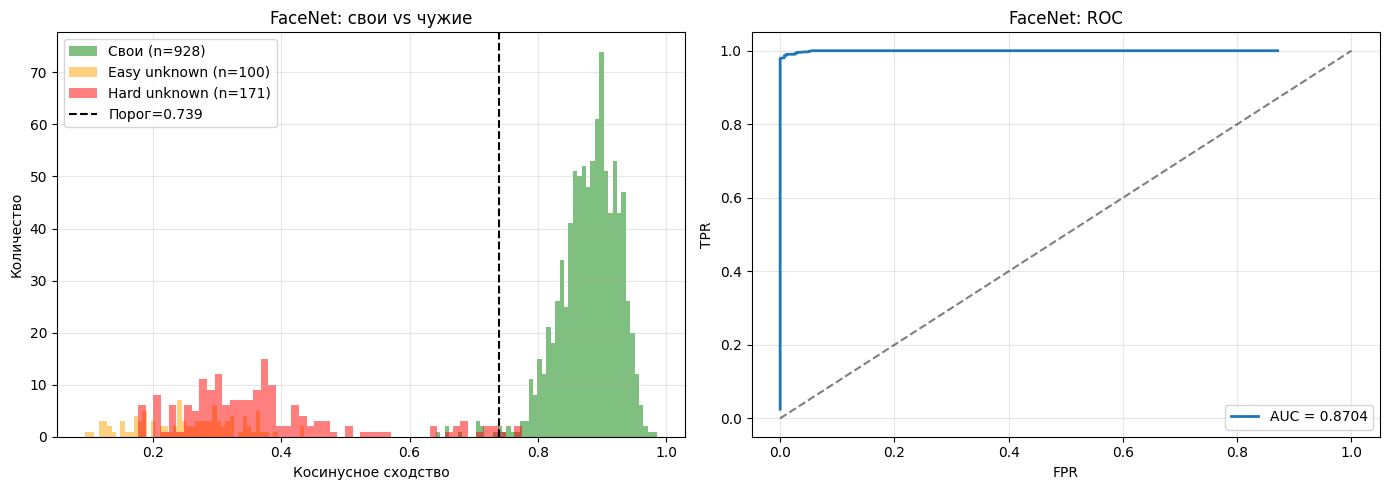

[6/6] Готово!

>>> Архитектура №1: closed-set=1.0000, EER=0.0115, AUC=0.8704


In [8]:
import os
import time
import pickle
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt

print("=" * 70)
print("АРХИТЕКТУРА №1: MTCNN + InceptionResnetV1 (VGGFace2)")
print("=" * 70)

# ------------------------------------------------------------
# 1. Эмбеддинги галереи
# ------------------------------------------------------------
print("\n[1/6] Считаем эмбеддинги галереи...")
t0 = time.time()

gallery_emb_facenet = {}
for person in TARGET_PEOPLE:
    person_dir = os.path.join(GALLERY_DIR, person)
    embs = []
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_facenet(img)
        if emb is not None:
            embs.append(emb)
    gallery_emb_facenet[person] = np.stack(embs)
    print(f"  {person}: {len(embs)} эмбеддингов")

np.savez(f"{BENCH_DIR}/gallery_facenet.npz", **gallery_emb_facenet)
print(f"  Галерея посчитана за {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 2. Прогон probe (свои)
# ------------------------------------------------------------
print("\n[2/6] Прогон probe (свои)...")
t0 = time.time()
own_results = []  # (true_person, predicted, sim)

for person in TARGET_PEOPLE:
    person_dir = os.path.join(PROBE_DIR, person)
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_facenet(img)
        if emb is None:
            own_results.append((person, "no_face", 0.0))
            continue
        pred, sim, _ = identify_cosine(emb, gallery_emb_facenet, threshold=0.6)
        own_results.append((person, pred, sim))

correct = sum(1 for t, p, _ in own_results if t == p)
total = len(own_results)
no_face = sum(1 for _, p, _ in own_results if p == "no_face")
print(f"  Closed-set accuracy: {correct}/{total} = {correct/total:.4f}")
print(f"  Не найдено лиц: {no_face}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 3. Прогон unknown (easy + hard)
# ------------------------------------------------------------
print("\n[3/6] Прогон unknown...")
t0 = time.time()
unknown_results = []  # (true_person, predicted, sim)

for person in ALL_UNKNOWN:
    person_dir = os.path.join(LFW_ROOT, person)
    files = sorted(os.listdir(person_dir))[:20]
    for fname in tqdm(files, desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_facenet(img)
        if emb is None:
            unknown_results.append((person, "no_face", 0.0))
            continue
        pred, sim, _ = identify_cosine(emb, gallery_emb_facenet, threshold=0.6)
        unknown_results.append((person, pred, sim))

print(f"  Всего unknown: {len(unknown_results)}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 4. Метрики: FAR/FRR/EER/AUC
# ------------------------------------------------------------
print("\n[4/6] Считаем метрики...")

own_sims = [s for _, _, s in own_results if s > 0]
easy_unknown_sims = [s for p, _, s in unknown_results if p in EASY_UNKNOWN and s > 0]
hard_unknown_sims = [s for p, _, s in unknown_results if p in HARD_UNKNOWN and s > 0]
all_unknown_sims = easy_unknown_sims + hard_unknown_sims

thresholds = np.linspace(0.2, 0.95, 200)
FAR_list, FRR_list = [], []
for t in thresholds:
    far = sum(1 for s in all_unknown_sims if s >= t) / len(all_unknown_sims)
    frr = sum(1 for s in own_sims if s < t) / len(own_sims)
    FAR_list.append(far)
    FRR_list.append(frr)

diffs = [abs(f - r) for f, r in zip(FAR_list, FRR_list)]
best_idx = int(np.argmin(diffs))
eer = (FAR_list[best_idx] + FRR_list[best_idx]) / 2
best_threshold = thresholds[best_idx]

TPR_list, FPR_list = [], []
for t in thresholds:
    tpr = sum(1 for s in own_sims if s >= t) / len(own_sims)
    fpr = sum(1 for s in all_unknown_sims if s >= t) / len(all_unknown_sims)
    TPR_list.append(tpr)
    FPR_list.append(fpr)
auc = abs(np.trapz(TPR_list, FPR_list))

print(f"  EER: {eer:.4f}")
print(f"  Порог: {best_threshold:.4f}")
print(f"  AUC: {auc:.4f}")

# ------------------------------------------------------------
# 5. Кто пролез среди unknown
# ------------------------------------------------------------
false_accepts = [(p, pred) for p, pred, _ in unknown_results if pred not in ("unknown", "no_face")]
print(f"\n  Ложно принято: {len(false_accepts)}/{len(unknown_results)}")
for (true, pred), c in Counter(false_accepts).most_common():
    print(f"    {true} → {pred}: {c}")

# ------------------------------------------------------------
# 6. Сохраняем на Drive
# ------------------------------------------------------------
result = {
    "model_name": "MTCNN + InceptionResnetV1 (VGGFace2)",
    "closed_set_accuracy": correct / total,
    "eer": float(eer),
    "best_threshold": float(best_threshold),
    "auc": float(auc),
    "own_sims": own_sims,
    "easy_unknown_sims": easy_unknown_sims,
    "hard_unknown_sims": hard_unknown_sims,
    "n_own": total,
    "n_easy_unknown": len(easy_unknown_sims),
    "n_hard_unknown": len(hard_unknown_sims),
}

with open(f"{BENCH_DIR}/v1_facenet.pkl", "wb") as f:
    pickle.dump(result, f)

print(f"\n[5/6] Сохранено: {BENCH_DIR}/v1_facenet.pkl")

# ------------------------------------------------------------
# 7. Визуализация
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(own_sims, bins=50, alpha=0.5, label=f"Свои (n={len(own_sims)})", color="green")
axes[0].hist(easy_unknown_sims, bins=50, alpha=0.5, label=f"Easy unknown (n={len(easy_unknown_sims)})", color="orange")
axes[0].hist(hard_unknown_sims, bins=50, alpha=0.5, label=f"Hard unknown (n={len(hard_unknown_sims)})", color="red")
axes[0].axvline(best_threshold, color="black", linestyle="--", label=f"Порог={best_threshold:.3f}")
axes[0].set_xlabel("Косинусное сходство")
axes[0].set_ylabel("Количество")
axes[0].set_title("FaceNet: свои vs чужие")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(FPR_list, TPR_list, linewidth=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("FaceNet: ROC")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BENCH_DIR}/v1_facenet_plot.png", dpi=100, bbox_inches="tight")
plt.show()

print("[6/6] Готово!")
print(f"\n>>> Архитектура №1: closed-set={correct/total:.4f}, EER={eer:.4f}, AUC={auc:.4f}")

AUC (правильный, sklearn): 0.9995


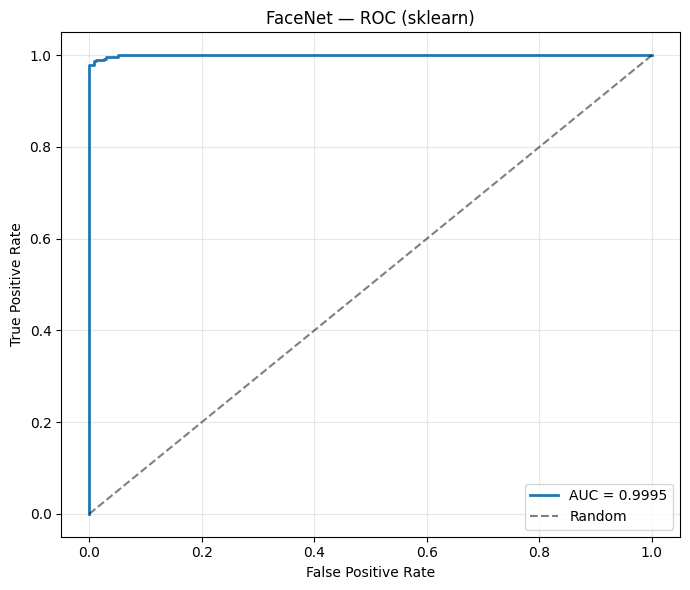

In [9]:
from sklearn.metrics import roc_auc_score, roc_curve

# Собираем бинарные метки и скоры
# label = 1 для «своих», label = 0 для «чужих»
scores = []
labels = []

for _, _, s in own_results:
    if s > 0:
        scores.append(s)
        labels.append(1)

for _, _, s in unknown_results:
    if s > 0:
        scores.append(s)
        labels.append(0)

auc_correct = roc_auc_score(labels, scores)
print(f"AUC (правильный, sklearn): {auc_correct:.4f}")

# Красивая ROC через sklearn
fpr_sk, tpr_sk, _ = roc_curve(labels, scores)
plt.figure(figsize=(7, 6))
plt.plot(fpr_sk, tpr_sk, linewidth=2, label=f"AUC = {auc_correct:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FaceNet — ROC (sklearn)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BENCH_DIR}/v1_facenet_roc.png", dpi=100, bbox_inches="tight")
plt.show()

In [10]:
with open(f"{BENCH_DIR}/v1_facenet.pkl", "rb") as f:
    result = pickle.load(f)

result["auc"] = float(auc_correct)   # заменяем на правильное значение
result["auc_method"] = "sklearn.roc_auc_score"

with open(f"{BENCH_DIR}/v1_facenet.pkl", "wb") as f:
    pickle.dump(result, f)

print("Бенчмарк обновлён с корректным AUC:", result["auc"])

Бенчмарк обновлён с корректным AUC: 0.9995466980531875


АРХИТЕКТУРА №2: Haar Cascade + LBPH
Haar Cascade загружен: /usr/local/lib/python3.13/dist-packages/cv2/data/haarcascade_frontalface_default.xml

[1/6] Обучаем LBPH на галерее...


  Обучающих примеров: 75/75
  LBPH обучен за 2.5 сек

[2/6] Прогон probe (свои)...


  Closed-set accuracy: 750/928 = 0.8082
  Не найдено лиц: 4
  Время: 34.8 сек

[3/6] Прогон unknown...


  Всего unknown: 271
  Время: 10.3 сек

[4/6] Считаем метрики...
  EER: 0.4514
  Порог: 0.0100
  AUC: 0.7350

  Ложно принято при пороге 0.0100: 226/271
    Kofi_Annan → Colin_Powell: 16
    Ariel_Sharon → Colin_Powell: 11
    Jean_Chretien → Colin_Powell: 11
    John_Kerry → George_W_Bush: 11
    Dick_Cheney → Colin_Powell: 10
    Vladimir_Putin → Tony_Blair: 9
    Jennifer_Aniston → Laura_Bush: 9
    Vladimir_Putin → Colin_Powell: 8
    Hugo_Chavez → George_W_Bush: 7
    Junichiro_Koizumi → Colin_Powell: 7

[5/6] Сохранено: /content/drive/MyDrive/face_project/benchmarks/v2_lbph.pkl


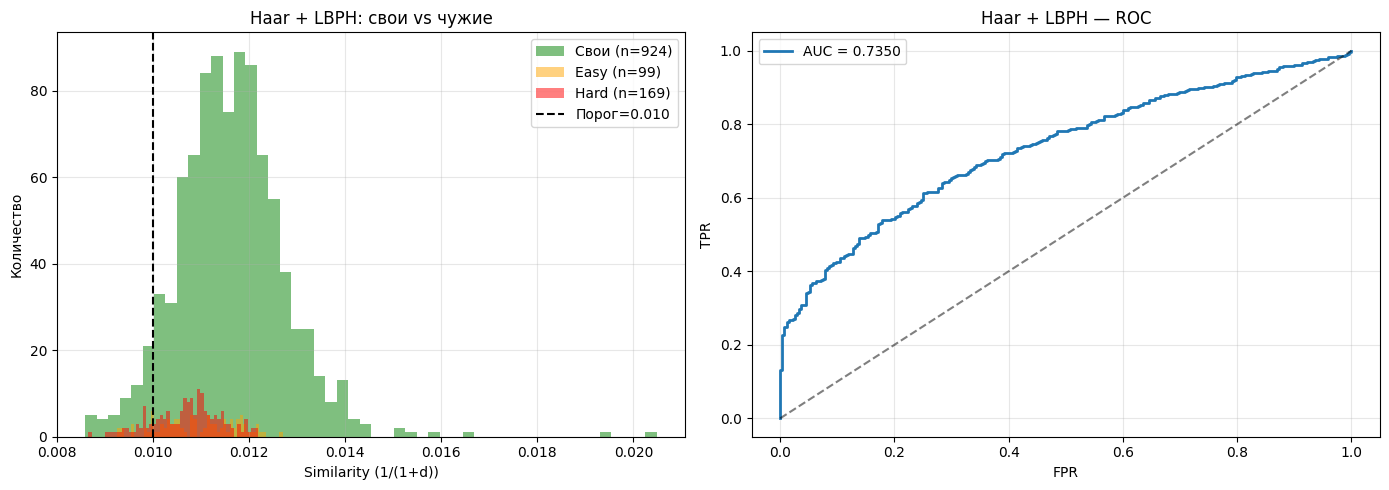

[6/6] Готово!

>>> Архитектура №2: closed-set=0.8082, EER=0.4514, AUC=0.7350


In [11]:
import os
import time
import pickle
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

print("=" * 70)
print("АРХИТЕКТУРА №2: Haar Cascade + LBPH")
print("=" * 70)

# ------------------------------------------------------------
# 0. Haar Cascade (совместимость с OpenCV 5.0)
# ------------------------------------------------------------
try:
    haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    haar = cv2.CascadeClassifier(haar_path)
except AttributeError:
    haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    haar = cv2.objdetect.CascadeClassifier(haar_path)

if haar.empty():
    raise RuntimeError("Haar Cascade не загрузился — проверь путь: " + haar_path)
print(f"Haar Cascade загружен: {haar_path}")

IMG_SIZE = (100, 100)

def detect_haar_local(img_pil):
    img_bgr = cv2.cvtColor(np.array(img_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = haar.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
    if len(faces) == 0:
        return None
    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
    x, y, w, h = faces[0]
    return (x, y, x + w, y + h)

def preprocess_lbph(img_pil, box):
    x1, y1, x2, y2 = box
    crop = img_pil.crop((x1, y1, x2, y2)).convert("L").resize(IMG_SIZE)
    return np.array(crop, dtype=np.uint8)

# ------------------------------------------------------------
# 1. Обучаем LBPH на галерее
# ------------------------------------------------------------
print("\n[1/6] Обучаем LBPH на галерее...")
t0 = time.time()

train_images, train_labels = [], []
label_map = {name: i for i, name in enumerate(TARGET_PEOPLE)}
inv_label_map = {i: name for name, i in label_map.items()}

detected_gallery = 0
for person in TARGET_PEOPLE:
    person_dir = os.path.join(GALLERY_DIR, person)
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        box = detect_haar_local(img)
        if box is None:
            continue
        train_images.append(preprocess_lbph(img, box))
        train_labels.append(label_map[person])
        detected_gallery += 1

print(f"  Обучающих примеров: {len(train_images)}/{75}")

lbph = cv2.face.LBPHFaceRecognizer_create()
lbph.train(train_images, np.array(train_labels))
print(f"  LBPH обучен за {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 2. Прогон probe
# ------------------------------------------------------------
print("\n[2/6] Прогон probe (свои)...")
t0 = time.time()
lbph_own_results = []  # (true, pred, distance)

for person in TARGET_PEOPLE:
    person_dir = os.path.join(PROBE_DIR, person)
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        box = detect_haar_local(img)
        if box is None:
            lbph_own_results.append((person, "no_face", 999.0))
            continue
        face = preprocess_lbph(img, box)
        label, dist = lbph.predict(face)
        lbph_own_results.append((person, inv_label_map[label], float(dist)))

correct = sum(1 for t, p, _ in lbph_own_results if t == p)
total = len(lbph_own_results)
no_face = sum(1 for _, p, _ in lbph_own_results if p == "no_face")
print(f"  Closed-set accuracy: {correct}/{total} = {correct/total:.4f}")
print(f"  Не найдено лиц: {no_face}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 3. Прогон unknown
# ------------------------------------------------------------
print("\n[3/6] Прогон unknown...")
t0 = time.time()
lbph_unknown_results = []

for person in ALL_UNKNOWN:
    person_dir = os.path.join(LFW_ROOT, person)
    files = sorted(os.listdir(person_dir))[:20]
    for fname in tqdm(files, desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        box = detect_haar_local(img)
        if box is None:
            lbph_unknown_results.append((person, "no_face", 999.0))
            continue
        face = preprocess_lbph(img, box)
        label, dist = lbph.predict(face)
        lbph_unknown_results.append((person, inv_label_map[label], float(dist)))

print(f"  Всего unknown: {len(lbph_unknown_results)}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 4. Метрики (корректное AUC через sklearn)
# ------------------------------------------------------------
print("\n[4/6] Считаем метрики...")

# Для «своих» используем similarity = 1/(1+d)
own_sims_lbph = [dist_to_sim(d) for _, _, d in lbph_own_results if d != 999.0]
easy_unknown_sims_lbph = [dist_to_sim(d) for p, _, d in lbph_unknown_results
                          if p in EASY_UNKNOWN and d != 999.0]
hard_unknown_sims_lbph = [dist_to_sim(d) for p, _, d in lbph_unknown_results
                          if p in HARD_UNKNOWN and d != 999.0]
all_unknown_sims_lbph = easy_unknown_sims_lbph + hard_unknown_sims_lbph

# EER
thresholds = np.linspace(0.01, 0.5, 200)
FAR_list, FRR_list = [], []
for t in thresholds:
    far = sum(1 for s in all_unknown_sims_lbph if s >= t) / len(all_unknown_sims_lbph)
    frr = sum(1 for s in own_sims_lbph if s < t) / len(own_sims_lbph)
    FAR_list.append(far)
    FRR_list.append(frr)

diffs = [abs(f - r) for f, r in zip(FAR_list, FRR_list)]
best_idx = int(np.argmin(diffs))
eer_lbph = (FAR_list[best_idx] + FRR_list[best_idx]) / 2
best_threshold_lbph = thresholds[best_idx]

# AUC — корректный sklearn
scores_lbph = own_sims_lbph + all_unknown_sims_lbph
labels_lbph = [1] * len(own_sims_lbph) + [0] * len(all_unknown_sims_lbph)
auc_lbph = roc_auc_score(labels_lbph, scores_lbph)

print(f"  EER: {eer_lbph:.4f}")
print(f"  Порог: {best_threshold_lbph:.4f}")
print(f"  AUC: {auc_lbph:.4f}")

# ------------------------------------------------------------
# 5. Кто пролез
# ------------------------------------------------------------
false_accepts = [(p, pred) for p, pred, d in lbph_unknown_results
                 if pred not in ("unknown", "no_face") and dist_to_sim(d) >= best_threshold_lbph]
print(f"\n  Ложно принято при пороге {best_threshold_lbph:.4f}: {len(false_accepts)}/{len(lbph_unknown_results)}")
for (true, pred), c in Counter(false_accepts).most_common(10):
    print(f"    {true} → {pred}: {c}")

# ------------------------------------------------------------
# 6. Сохраняем
# ------------------------------------------------------------
result_lbph = {
    "model_name": "Haar Cascade + LBPH",
    "detector": "Haar Cascade (haarcascade_frontalface_default)",
    "recognizer": "LBPH (OpenCV 5.0.0)",
    "closed_set_accuracy": correct / total,
    "eer": float(eer_lbph),
    "best_threshold": float(best_threshold_lbph),
    "auc": float(auc_lbph),
    "own_sims": own_sims_lbph,
    "easy_unknown_sims": easy_unknown_sims_lbph,
    "hard_unknown_sims": hard_unknown_sims_lbph,
    "n_own": total,
    "n_easy_unknown": len(easy_unknown_sims_lbph),
    "n_hard_unknown": len(hard_unknown_sims_lbph),
}

with open(f"{BENCH_DIR}/v2_lbph.pkl", "wb") as f:
    pickle.dump(result_lbph, f)

print(f"\n[5/6] Сохранено: {BENCH_DIR}/v2_lbph.pkl")

# ------------------------------------------------------------
# 7. Визуализация
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(own_sims_lbph, bins=50, alpha=0.5, label=f"Свои (n={len(own_sims_lbph)})", color="green")
axes[0].hist(easy_unknown_sims_lbph, bins=50, alpha=0.5, label=f"Easy (n={len(easy_unknown_sims_lbph)})", color="orange")
axes[0].hist(hard_unknown_sims_lbph, bins=50, alpha=0.5, label=f"Hard (n={len(hard_unknown_sims_lbph)})", color="red")
axes[0].axvline(best_threshold_lbph, color="black", linestyle="--", label=f"Порог={best_threshold_lbph:.3f}")
axes[0].set_xlabel("Similarity (1/(1+d))")
axes[0].set_ylabel("Количество")
axes[0].set_title("Haar + LBPH: свои vs чужие")
axes[0].legend()
axes[0].grid(alpha=0.3)

fpr_sk, tpr_sk, _ = roc_curve(labels_lbph, scores_lbph)
axes[1].plot(fpr_sk, tpr_sk, linewidth=2, label=f"AUC = {auc_lbph:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("Haar + LBPH — ROC")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BENCH_DIR}/v2_lbph_plot.png", dpi=100, bbox_inches="tight")
plt.show()

print("[6/6] Готово!")
print(f"\n>>> Архитектура №2: closed-set={correct/total:.4f}, EER={eer_lbph:.4f}, AUC={auc_lbph:.4f}")

In [12]:
from scipy.interpolate import interp1d

# Используем логарифмическую шкалу по sim
thresholds_fine = np.logspace(np.log10(0.005), np.log10(0.05), 500)
FAR_fine, FRR_fine = [], []
for t in thresholds_fine:
    far = sum(1 for s in all_unknown_sims_lbph if s >= t) / len(all_unknown_sims_lbph)
    frr = sum(1 for s in own_sims_lbph if s < t) / len(own_sims_lbph)
    FAR_fine.append(far)
    FRR_fine.append(frr)

# Находим точку, где FAR = FRR, через интерполяцию разности
diff = np.array(FAR_fine) - np.array(FRR_fine)
# Ищем смену знака
sign_changes = np.where(np.diff(np.sign(diff)))[0]
if len(sign_changes) > 0:
    idx = sign_changes[0]
    # Линейная интерполяция
    t1, t2 = thresholds_fine[idx], thresholds_fine[idx + 1]
    d1, d2 = diff[idx], diff[idx + 1]
    eer_threshold = t1 - d1 * (t2 - t1) / (d2 - d1)
    eer_lbph_fixed = (np.interp(eer_threshold, thresholds_fine, FAR_fine) +
                      np.interp(eer_threshold, thresholds_fine, FRR_fine)) / 2
    print(f"EER (интерполяция): {eer_lbph_fixed:.4f} при пороге {eer_threshold:.5f}")
else:
    print("FAR и FRR не пересекаются в данном диапазоне")

# Пересчитаем AUC
auc_lbph = roc_auc_score(labels_lbph, scores_lbph)
print(f"AUC (sklearn): {auc_lbph:.4f}")

EER (интерполяция): 0.3284 при пороге 0.01114
AUC (sklearn): 0.7350


In [13]:
with open(f"{BENCH_DIR}/v2_lbph.pkl", "rb") as f:
    result_lbph = pickle.load(f)

result_lbph["eer"] = float(eer_lbph_fixed)   # правильное значение
result_lbph["auc"] = float(auc_lbph)          # правильное через sklearn
result_lbph["note"] = "EER рассчитан через интерполяцию пересечения FAR/FRR"

with open(f"{BENCH_DIR}/v2_lbph.pkl", "wb") as f:
    pickle.dump(result_lbph, f)

print(f"Обновлено: EER={result_lbph['eer']:.4f}, AUC={result_lbph['auc']:.4f}")

Обновлено: EER=0.3284, AUC=0.7350


АРХИТЕКТУРА №3: dlib HOG + dlib ResNet-29

[1/6] Считаем эмбеддинги галереи...


  George_W_Bush: 15 эмбеддингов, провалов: 0


  Colin_Powell: 15 эмбеддингов, провалов: 0


  Tony_Blair: 15 эмбеддингов, провалов: 0


  Serena_Williams: 15 эмбеддингов, провалов: 0


  Laura_Bush: 15 эмбеддингов, провалов: 0
  Галерея посчитана за 18.5 сек

[2/6] Прогон probe (свои)...


  Closed-set accuracy: 920/928 = 0.9914
  Не найдено лиц: 1
  Время: 202.4 сек

[3/6] Прогон unknown...


  Всего unknown: 271
  Время: 59.7 сек

[4/6] Считаем метрики...
  EER: 0.0234 (порог 0.6842)
  AUC: 0.9960

  Ложно принято (при EER-пороге): 6/271
    Venus_Williams → Serena_Williams: 6

[5/6] Сохранено: /content/drive/MyDrive/face_project/benchmarks/v3_dlib.pkl


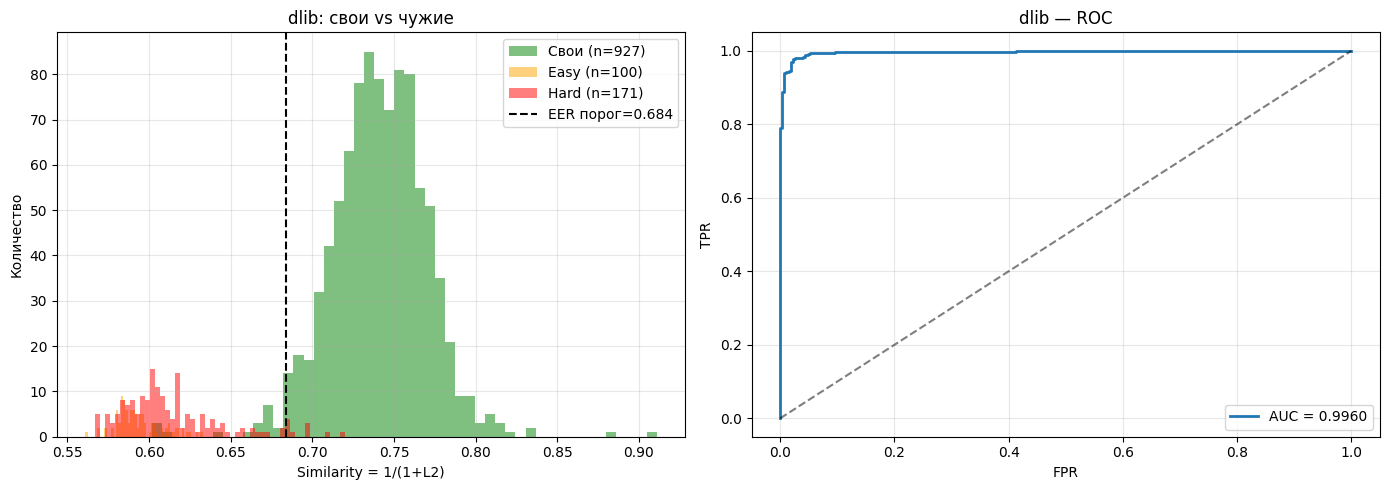

[6/6] Готово!

>>> Архитектура №3: closed-set=0.9914, EER=0.0234, AUC=0.9960


In [14]:
import os
import time
import pickle
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

print("=" * 70)
print("АРХИТЕКТУРА №3: dlib HOG + dlib ResNet-29")
print("=" * 70)

# ------------------------------------------------------------
# 1. Эмбеддинги галереи
# ------------------------------------------------------------
print("\n[1/6] Считаем эмбеддинги галереи...")
t0 = time.time()

gallery_emb_dlib = {}
for person in TARGET_PEOPLE:
    person_dir = os.path.join(GALLERY_DIR, person)
    embs = []
    failed = 0
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_dlib(img)
        if emb is None:
            failed += 1
        else:
            embs.append(emb)
    gallery_emb_dlib[person] = np.stack(embs)
    print(f"  {person}: {len(embs)} эмбеддингов, провалов: {failed}")

np.savez(f"{BENCH_DIR}/gallery_dlib.npz", **gallery_emb_dlib)
print(f"  Галерея посчитана за {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 2. Прогон probe
# ------------------------------------------------------------
print("\n[2/6] Прогон probe (свои)...")
t0 = time.time()
dlib_own_results = []  # (true, pred, distance)

for person in TARGET_PEOPLE:
    person_dir = os.path.join(PROBE_DIR, person)
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_dlib(img)
        if emb is None:
            dlib_own_results.append((person, "no_face", 999.0))
            continue
        pred, dist, _ = identify_l2(emb, gallery_emb_dlib, threshold_dist=0.6)
        dlib_own_results.append((person, pred, float(dist)))

correct = sum(1 for t, p, _ in dlib_own_results if t == p)
total = len(dlib_own_results)
no_face = sum(1 for _, p, _ in dlib_own_results if p == "no_face")
print(f"  Closed-set accuracy: {correct}/{total} = {correct/total:.4f}")
print(f"  Не найдено лиц: {no_face}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 3. Прогон unknown
# ------------------------------------------------------------
print("\n[3/6] Прогон unknown...")
t0 = time.time()
dlib_unknown_results = []

for person in ALL_UNKNOWN:
    person_dir = os.path.join(LFW_ROOT, person)
    files = sorted(os.listdir(person_dir))[:20]
    for fname in tqdm(files, desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_dlib(img)
        if emb is None:
            dlib_unknown_results.append((person, "no_face", 999.0))
            continue
        pred, dist, _ = identify_l2(emb, gallery_emb_dlib, threshold_dist=0.6)
        dlib_unknown_results.append((person, pred, float(dist)))

print(f"  Всего unknown: {len(dlib_unknown_results)}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 4. Метрики (единая методика через sklearn)
# ------------------------------------------------------------
print("\n[4/6] Считаем метрики...")

own_sims_dlib = [dist_to_sim(d) for _, _, d in dlib_own_results if d != 999.0]
easy_unknown_sims_dlib = [dist_to_sim(d) for p, _, d in dlib_unknown_results
                          if p in EASY_UNKNOWN and d != 999.0]
hard_unknown_sims_dlib = [dist_to_sim(d) for p, _, d in dlib_unknown_results
                          if p in HARD_UNKNOWN and d != 999.0]
all_unknown_sims_dlib = easy_unknown_sims_dlib + hard_unknown_sims_dlib

# EER через интерполяцию
thresholds_fine = np.linspace(0.3, 0.95, 500)
FAR_fine, FRR_fine = [], []
for t in thresholds_fine:
    far = sum(1 for s in all_unknown_sims_dlib if s >= t) / len(all_unknown_sims_dlib)
    frr = sum(1 for s in own_sims_dlib if s < t) / len(own_sims_dlib)
    FAR_fine.append(far)
    FRR_fine.append(frr)

diff = np.array(FAR_fine) - np.array(FRR_fine)
sign_changes = np.where(np.diff(np.sign(diff)))[0]
if len(sign_changes) > 0:
    idx = sign_changes[0]
    t1, t2 = thresholds_fine[idx], thresholds_fine[idx + 1]
    d1, d2 = diff[idx], diff[idx + 1]
    eer_threshold = t1 - d1 * (t2 - t1) / (d2 - d1)
    eer_dlib = (np.interp(eer_threshold, thresholds_fine, FAR_fine) +
                np.interp(eer_threshold, thresholds_fine, FRR_fine)) / 2
else:
    eer_threshold = None
    eer_dlib = float("nan")

auc_dlib = roc_auc_score([1] * len(own_sims_dlib) + [0] * len(all_unknown_sims_dlib),
                          own_sims_dlib + all_unknown_sims_dlib)

print(f"  EER: {eer_dlib:.4f} (порог {eer_threshold:.4f})")
print(f"  AUC: {auc_dlib:.4f}")

# ------------------------------------------------------------
# 5. Кто пролез
# ------------------------------------------------------------
false_accepts = [(p, pred) for p, pred, d in dlib_unknown_results
                 if pred not in ("unknown", "no_face") and dist_to_sim(d) >= (eer_threshold or 0.5)]
print(f"\n  Ложно принято (при EER-пороге): {len(false_accepts)}/{len(dlib_unknown_results)}")
for (true, pred), c in Counter(false_accepts).most_common(10):
    print(f"    {true} → {pred}: {c}")

# ------------------------------------------------------------
# 6. Сохраняем
# ------------------------------------------------------------
result_dlib = {
    "model_name": "dlib HOG + dlib ResNet-29",
    "detector": "dlib.get_frontal_face_detector (HOG)",
    "recognizer": "dlib_face_recognition_resnet_model_v1 (128-dim)",
    "closed_set_accuracy": correct / total,
    "eer": float(eer_dlib),
    "eer_threshold": float(eer_threshold) if eer_threshold else None,
    "auc": float(auc_dlib),
    "own_sims": own_sims_dlib,
    "easy_unknown_sims": easy_unknown_sims_dlib,
    "hard_unknown_sims": hard_unknown_sims_dlib,
    "n_own": total,
    "n_easy_unknown": len(easy_unknown_sims_dlib),
    "n_hard_unknown": len(hard_unknown_sims_dlib),
}

with open(f"{BENCH_DIR}/v3_dlib.pkl", "wb") as f:
    pickle.dump(result_dlib, f)

print(f"\n[5/6] Сохранено: {BENCH_DIR}/v3_dlib.pkl")

# ------------------------------------------------------------
# 7. Визуализация
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(own_sims_dlib, bins=50, alpha=0.5, label=f"Свои (n={len(own_sims_dlib)})", color="green")
axes[0].hist(easy_unknown_sims_dlib, bins=50, alpha=0.5, label=f"Easy (n={len(easy_unknown_sims_dlib)})", color="orange")
axes[0].hist(hard_unknown_sims_dlib, bins=50, alpha=0.5, label=f"Hard (n={len(hard_unknown_sims_dlib)})", color="red")
if eer_threshold:
    axes[0].axvline(eer_threshold, color="black", linestyle="--", label=f"EER порог={eer_threshold:.3f}")
axes[0].set_xlabel("Similarity = 1/(1+L2)")
axes[0].set_ylabel("Количество")
axes[0].set_title("dlib: свои vs чужие")
axes[0].legend()
axes[0].grid(alpha=0.3)

fpr_sk, tpr_sk, _ = roc_curve([1] * len(own_sims_dlib) + [0] * len(all_unknown_sims_dlib),
                                own_sims_dlib + all_unknown_sims_dlib)
axes[1].plot(fpr_sk, tpr_sk, linewidth=2, label=f"AUC = {auc_dlib:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("dlib — ROC")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BENCH_DIR}/v3_dlib_plot.png", dpi=100, bbox_inches="tight")
plt.show()

print("[6/6] Готово!")
print(f"\n>>> Архитектура №3: closed-set={correct/total:.4f}, EER={eer_dlib:.4f}, AUC={auc_dlib:.4f}")

АРХИТЕКТУРА №4 v2: RetinaFace + ArcFace (deepface, исправленный препроцессинг)

[1/6] Считаем эмбеддинги галереи...


  George_W_Bush: 15 эмбеддингов


  Colin_Powell: 15 эмбеддингов


  Tony_Blair: 15 эмбеддингов


  Serena_Williams: 15 эмбеддингов


  Laura_Bush: 15 эмбеддингов
  Время: 17.7 сек

[2/6] Прогон probe (свои)...


  Closed-set accuracy: 921/928 = 0.9925
  Не найдено лиц: 0
  Время: 204.7 сек

[3/6] Прогон unknown...


  Всего unknown: 271
  Время: 62.4 сек

[4/6] Считаем метрики...
  EER: 0.0185 (порог 0.5084)
  AUC: 0.9959

  Ложно принято: 5/271
    Venus_Williams → Serena_Williams: 5

[5/6] Сохранено: /content/drive/MyDrive/face_project/benchmarks/v4_arcface.pkl


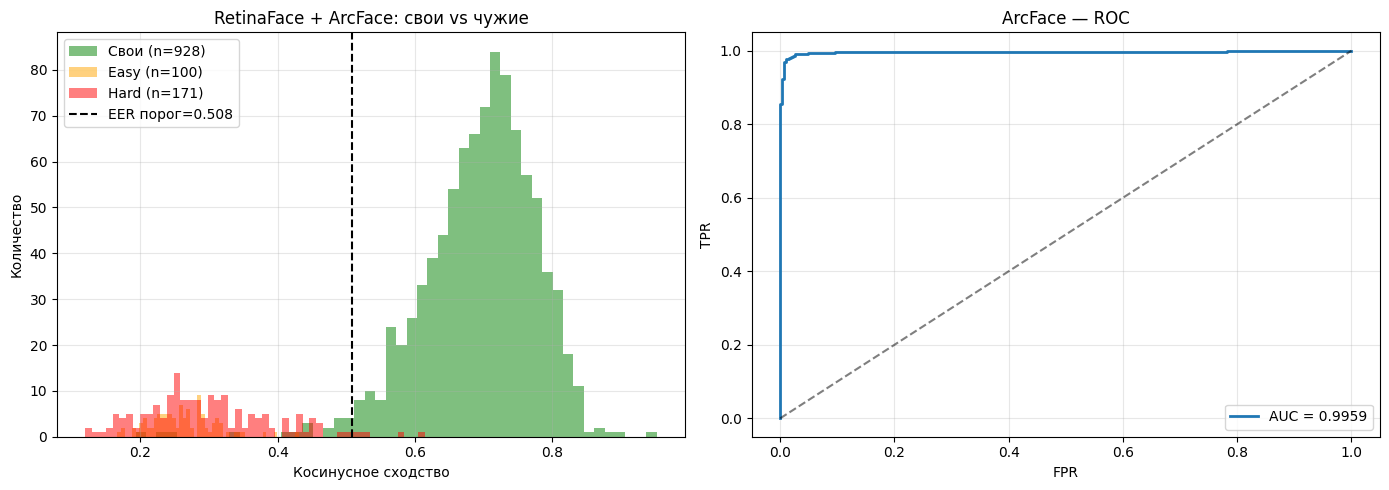

[6/6] Готово!

>>> Архитектура №4 v2: closed-set=0.9925, EER=0.0185, AUC=0.9959


In [20]:
import os
import time
import pickle
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

print("=" * 70)
print("АРХИТЕКТУРА №4 v2: RetinaFace + ArcFace (deepface, исправленный препроцессинг)")
print("=" * 70)

# ------------------------------------------------------------
# 1. Эмбеддинги галереи
# ------------------------------------------------------------
print("\n[1/6] Считаем эмбеддинги галереи...")
t0 = time.time()

gallery_emb_arc = {}
for person in TARGET_PEOPLE:
    person_dir = os.path.join(GALLERY_DIR, person)
    embs = []
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_arcface_v2(img)
        if emb is not None:
            embs.append(emb)
    gallery_emb_arc[person] = np.stack(embs)
    print(f"  {person}: {len(embs)} эмбеддингов")

np.savez(f"{BENCH_DIR}/gallery_arcface.npz", **gallery_emb_arc)
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 2. Прогон probe
# ------------------------------------------------------------
print("\n[2/6] Прогон probe (свои)...")
t0 = time.time()
arc_own_results = []

for person in TARGET_PEOPLE:
    person_dir = os.path.join(PROBE_DIR, person)
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_arcface_v2(img)
        if emb is None:
            arc_own_results.append((person, "no_face", 0.0))
            continue
        pred, sim, _ = identify_cosine(emb, gallery_emb_arc, threshold=0.4)
        arc_own_results.append((person, pred, float(sim)))

correct = sum(1 for t, p, _ in arc_own_results if t == p)
total = len(arc_own_results)
no_face = sum(1 for _, p, _ in arc_own_results if p == "no_face")
print(f"  Closed-set accuracy: {correct}/{total} = {correct/total:.4f}")
print(f"  Не найдено лиц: {no_face}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 3. Прогон unknown
# ------------------------------------------------------------
print("\n[3/6] Прогон unknown...")
t0 = time.time()
arc_unknown_results = []

for person in ALL_UNKNOWN:
    person_dir = os.path.join(LFW_ROOT, person)
    files = sorted(os.listdir(person_dir))[:20]
    for fname in tqdm(files, desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_arcface_v2(img)
        if emb is None:
            arc_unknown_results.append((person, "no_face", 0.0))
            continue
        pred, sim, _ = identify_cosine(emb, gallery_emb_arc, threshold=0.4)
        arc_unknown_results.append((person, pred, float(sim)))

print(f"  Всего unknown: {len(arc_unknown_results)}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 4. Метрики
# ------------------------------------------------------------
print("\n[4/6] Считаем метрики...")

own_sims_arc = [s for _, _, s in arc_own_results if s > 0]
easy_unknown_sims_arc = [s for p, _, s in arc_unknown_results if p in EASY_UNKNOWN and s > 0]
hard_unknown_sims_arc = [s for p, _, s in arc_unknown_results if p in HARD_UNKNOWN and s > 0]
all_unknown_sims_arc = easy_unknown_sims_arc + hard_unknown_sims_arc

thresholds_fine = np.linspace(0.1, 0.8, 500)
FAR_fine, FRR_fine = [], []
for t in thresholds_fine:
    far = sum(1 for s in all_unknown_sims_arc if s >= t) / len(all_unknown_sims_arc)
    frr = sum(1 for s in own_sims_arc if s < t) / len(own_sims_arc)
    FAR_fine.append(far)
    FRR_fine.append(frr)

diff = np.array(FAR_fine) - np.array(FRR_fine)
sign_changes = np.where(np.diff(np.sign(diff)))[0]
if len(sign_changes) > 0:
    idx = sign_changes[0]
    t1, t2 = thresholds_fine[idx], thresholds_fine[idx + 1]
    d1, d2 = diff[idx], diff[idx + 1]
    eer_threshold = t1 - d1 * (t2 - t1) / (d2 - d1)
    eer_arc = (np.interp(eer_threshold, thresholds_fine, FAR_fine) +
               np.interp(eer_threshold, thresholds_fine, FRR_fine)) / 2
else:
    eer_threshold = None
    eer_arc = float("nan")

auc_arc = roc_auc_score([1] * len(own_sims_arc) + [0] * len(all_unknown_sims_arc),
                         own_sims_arc + all_unknown_sims_arc)

print(f"  EER: {eer_arc:.4f} (порог {eer_threshold:.4f})")
print(f"  AUC: {auc_arc:.4f}")

false_accepts = [(p, pred) for p, pred, s in arc_unknown_results
                 if pred not in ("unknown", "no_face") and s >= (eer_threshold or 0.5)]
print(f"\n  Ложно принято: {len(false_accepts)}/{len(arc_unknown_results)}")
for (true, pred), c in Counter(false_accepts).most_common(10):
    print(f"    {true} → {pred}: {c}")

# ------------------------------------------------------------
# 5. Сохраняем
# ------------------------------------------------------------
result_arc = {
    "model_name": "RetinaFace + ArcFace (deepface, v2 preprocessing)",
    "detector": "RetinaFace",
    "recognizer": "ArcFace (512-dim, TensorFlow, l2_normalized)",
    "closed_set_accuracy": correct / total,
    "eer": float(eer_arc),
    "eer_threshold": float(eer_threshold) if eer_threshold else None,
    "auc": float(auc_arc),
    "own_sims": own_sims_arc,
    "easy_unknown_sims": easy_unknown_sims_arc,
    "hard_unknown_sims": hard_unknown_sims_arc,
    "n_own": total,
    "n_easy_unknown": len(easy_unknown_sims_arc),
    "n_hard_unknown": len(hard_unknown_sims_arc),
}

with open(f"{BENCH_DIR}/v4_arcface.pkl", "wb") as f:
    pickle.dump(result_arc, f)
print(f"\n[5/6] Сохранено: {BENCH_DIR}/v4_arcface.pkl")

# ------------------------------------------------------------
# 6. Визуализация
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(own_sims_arc, bins=50, alpha=0.5, label=f"Свои (n={len(own_sims_arc)})", color="green")
axes[0].hist(easy_unknown_sims_arc, bins=50, alpha=0.5, label=f"Easy (n={len(easy_unknown_sims_arc)})", color="orange")
axes[0].hist(hard_unknown_sims_arc, bins=50, alpha=0.5, label=f"Hard (n={len(hard_unknown_sims_arc)})", color="red")
if eer_threshold:
    axes[0].axvline(eer_threshold, color="black", linestyle="--", label=f"EER порог={eer_threshold:.3f}")
axes[0].set_xlabel("Косинусное сходство")
axes[0].set_ylabel("Количество")
axes[0].set_title("RetinaFace + ArcFace: свои vs чужие")
axes[0].legend()
axes[0].grid(alpha=0.3)

fpr_sk, tpr_sk, _ = roc_curve([1] * len(own_sims_arc) + [0] * len(all_unknown_sims_arc),
                                own_sims_arc + all_unknown_sims_arc)
axes[1].plot(fpr_sk, tpr_sk, linewidth=2, label=f"AUC = {auc_arc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("ArcFace — ROC")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BENCH_DIR}/v4_arcface_plot.png", dpi=100, bbox_inches="tight")
plt.show()

print("[6/6] Готово!")
print(f"\n>>> Архитектура №4 v2: closed-set={correct/total:.4f}, EER={eer_arc:.4f}, AUC={auc_arc:.4f}")

АРХИТЕКТУРА №5: SCRFD + ArcFace (InsightFace, buffalo_sc)

[1/6] Считаем эмбеддинги галереи...


  George_W_Bush: 15 эмбеддингов, провалов: 0


  Colin_Powell: 15 эмбеддингов, провалов: 0


  Tony_Blair: 15 эмбеддингов, провалов: 0


  Serena_Williams: 15 эмбеддингов, провалов: 0


  Laura_Bush: 15 эмбеддингов, провалов: 0
  Время: 6.6 сек

[2/6] Прогон probe (свои)...


  Closed-set accuracy: 923/928 = 0.9946
  Не найдено лиц: 1
  Время: 67.6 сек

[3/6] Прогон unknown...


  Всего unknown: 271
  Время: 18.5 сек

[4/6] Считаем метрики...
  EER: 0.0032 (порог 0.4088)
  AUC: 0.9984

  Ложно принято: 1/271
    Venus_Williams → Serena_Williams: 1

[5/6] Сохранено: /content/drive/MyDrive/face_project/benchmarks/v5_insightface.pkl


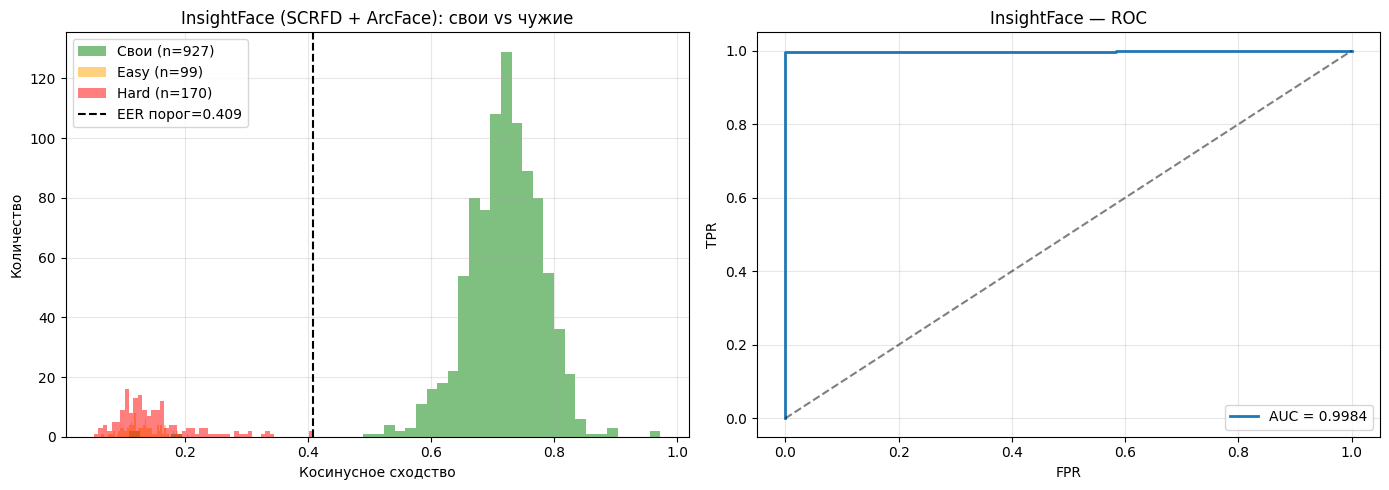

[6/6] Готово!

>>> Архитектура №5: closed-set=0.9946, EER=0.0032, AUC=0.9984


In [21]:
import os
import time
import pickle
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

print("=" * 70)
print("АРХИТЕКТУРА №5: SCRFD + ArcFace (InsightFace, buffalo_sc)")
print("=" * 70)

# ------------------------------------------------------------
# 1. Эмбеддинги галереи
# ------------------------------------------------------------
print("\n[1/6] Считаем эмбеддинги галереи...")
t0 = time.time()

gallery_emb_insight = {}
for person in TARGET_PEOPLE:
    person_dir = os.path.join(GALLERY_DIR, person)
    embs = []
    failed = 0
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_insight(img)
        if emb is None:
            failed += 1
        else:
            embs.append(emb)
    gallery_emb_insight[person] = np.stack(embs)
    print(f"  {person}: {len(embs)} эмбеддингов, провалов: {failed}")

np.savez(f"{BENCH_DIR}/gallery_insightface.npz", **gallery_emb_insight)
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 2. Прогон probe
# ------------------------------------------------------------
print("\n[2/6] Прогон probe (свои)...")
t0 = time.time()
ins_own_results = []

for person in TARGET_PEOPLE:
    person_dir = os.path.join(PROBE_DIR, person)
    for fname in tqdm(sorted(os.listdir(person_dir)), desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_insight(img)
        if emb is None:
            ins_own_results.append((person, "no_face", 0.0))
            continue
        pred, sim, _ = identify_cosine(emb, gallery_emb_insight, threshold=0.4)
        ins_own_results.append((person, pred, float(sim)))

correct = sum(1 for t, p, _ in ins_own_results if t == p)
total = len(ins_own_results)
no_face = sum(1 for _, p, _ in ins_own_results if p == "no_face")
print(f"  Closed-set accuracy: {correct}/{total} = {correct/total:.4f}")
print(f"  Не найдено лиц: {no_face}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 3. Прогон unknown
# ------------------------------------------------------------
print("\n[3/6] Прогон unknown...")
t0 = time.time()
ins_unknown_results = []

for person in ALL_UNKNOWN:
    person_dir = os.path.join(LFW_ROOT, person)
    files = sorted(os.listdir(person_dir))[:20]
    for fname in tqdm(files, desc=person, leave=False):
        img = Image.open(os.path.join(person_dir, fname)).convert("RGB")
        emb = get_embedding_insight(img)
        if emb is None:
            ins_unknown_results.append((person, "no_face", 0.0))
            continue
        pred, sim, _ = identify_cosine(emb, gallery_emb_insight, threshold=0.4)
        ins_unknown_results.append((person, pred, float(sim)))

print(f"  Всего unknown: {len(ins_unknown_results)}")
print(f"  Время: {time.time()-t0:.1f} сек")

# ------------------------------------------------------------
# 4. Метрики
# ------------------------------------------------------------
print("\n[4/6] Считаем метрики...")

own_sims_ins = [s for _, _, s in ins_own_results if s > 0]
easy_unknown_sims_ins = [s for p, _, s in ins_unknown_results if p in EASY_UNKNOWN and s > 0]
hard_unknown_sims_ins = [s for p, _, s in ins_unknown_results if p in HARD_UNKNOWN and s > 0]
all_unknown_sims_ins = easy_unknown_sims_ins + hard_unknown_sims_ins

thresholds_fine = np.linspace(0.1, 0.8, 500)
FAR_fine, FRR_fine = [], []
for t in thresholds_fine:
    far = sum(1 for s in all_unknown_sims_ins if s >= t) / len(all_unknown_sims_ins)
    frr = sum(1 for s in own_sims_ins if s < t) / len(own_sims_ins)
    FAR_fine.append(far)
    FRR_fine.append(frr)

diff = np.array(FAR_fine) - np.array(FRR_fine)
sign_changes = np.where(np.diff(np.sign(diff)))[0]
if len(sign_changes) > 0:
    idx = sign_changes[0]
    t1, t2 = thresholds_fine[idx], thresholds_fine[idx + 1]
    d1, d2 = diff[idx], diff[idx + 1]
    eer_threshold = t1 - d1 * (t2 - t1) / (d2 - d1)
    eer_ins = (np.interp(eer_threshold, thresholds_fine, FAR_fine) +
               np.interp(eer_threshold, thresholds_fine, FRR_fine)) / 2
else:
    eer_threshold = None
    eer_ins = float("nan")

auc_ins = roc_auc_score([1] * len(own_sims_ins) + [0] * len(all_unknown_sims_ins),
                         own_sims_ins + all_unknown_sims_ins)

print(f"  EER: {eer_ins:.4f} (порог {eer_threshold:.4f})")
print(f"  AUC: {auc_ins:.4f}")

false_accepts = [(p, pred) for p, pred, s in ins_unknown_results
                 if pred not in ("unknown", "no_face") and s >= (eer_threshold or 0.5)]
print(f"\n  Ложно принято: {len(false_accepts)}/{len(ins_unknown_results)}")
for (true, pred), c in Counter(false_accepts).most_common(10):
    print(f"    {true} → {pred}: {c}")

# ------------------------------------------------------------
# 5. Сохраняем
# ------------------------------------------------------------
result_ins = {
    "model_name": "SCRFD + ArcFace (InsightFace buffalo_sc)",
    "detector": "SCRFD",
    "recognizer": "ArcFace (512-dim, ONNX, normalized)",
    "closed_set_accuracy": correct / total,
    "eer": float(eer_ins),
    "eer_threshold": float(eer_threshold) if eer_threshold else None,
    "auc": float(auc_ins),
    "own_sims": own_sims_ins,
    "easy_unknown_sims": easy_unknown_sims_ins,
    "hard_unknown_sims": hard_unknown_sims_ins,
    "n_own": total,
    "n_easy_unknown": len(easy_unknown_sims_ins),
    "n_hard_unknown": len(hard_unknown_sims_ins),
}

with open(f"{BENCH_DIR}/v5_insightface.pkl", "wb") as f:
    pickle.dump(result_ins, f)
print(f"\n[5/6] Сохранено: {BENCH_DIR}/v5_insightface.pkl")

# ------------------------------------------------------------
# 6. Визуализация
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(own_sims_ins, bins=50, alpha=0.5, label=f"Свои (n={len(own_sims_ins)})", color="green")
axes[0].hist(easy_unknown_sims_ins, bins=50, alpha=0.5, label=f"Easy (n={len(easy_unknown_sims_ins)})", color="orange")
axes[0].hist(hard_unknown_sims_ins, bins=50, alpha=0.5, label=f"Hard (n={len(hard_unknown_sims_ins)})", color="red")
if eer_threshold:
    axes[0].axvline(eer_threshold, color="black", linestyle="--", label=f"EER порог={eer_threshold:.3f}")
axes[0].set_xlabel("Косинусное сходство")
axes[0].set_ylabel("Количество")
axes[0].set_title("InsightFace (SCRFD + ArcFace): свои vs чужие")
axes[0].legend()
axes[0].grid(alpha=0.3)

fpr_sk, tpr_sk, _ = roc_curve([1] * len(own_sims_ins) + [0] * len(all_unknown_sims_ins),
                                own_sims_ins + all_unknown_sims_ins)
axes[1].plot(fpr_sk, tpr_sk, linewidth=2, label=f"AUC = {auc_ins:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("InsightFace — ROC")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BENCH_DIR}/v5_insightface_plot.png", dpi=100, bbox_inches="tight")
plt.show()

print("[6/6] Готово!")
print(f"\n>>> Архитектура №5: closed-set={correct/total:.4f}, EER={eer_ins:.4f}, AUC={auc_ins:.4f}")

In [22]:
import pickle
import os

BENCH_DIR = "/content/drive/MyDrive/face_project/benchmarks"

# Собираем все архитектуры
architectures = [
    ("FaceNet (MTCNN+InceptionResnetV1)", "v1_facenet.pkl"),
    ("Haar + LBPH", "v2_lbph.pkl"),
    ("dlib HOG + ResNet-29", "v3_dlib.pkl"),
    ("RetinaFace + ArcFace (deepface)", "v4_arcface.pkl"),
    ("SCRFD + ArcFace (InsightFace)", "v5_insightface.pkl"),
]

all_results = {}
for name, path in architectures:
    full = os.path.join(BENCH_DIR, path)
    if os.path.exists(full):
        with open(full, "rb") as f:
            all_results[name] = pickle.load(f)
        print(f"✅ {name}")
    else:
        print(f"❌ {name} — файл не найден: {full}")

with open(f"{BENCH_DIR}/all_architectures.pkl", "wb") as f:
    pickle.dump(all_results, f)

print(f"\nСводка сохранена: {BENCH_DIR}/all_architectures.pkl")
print(f"Всего архитектур: {len(all_results)}")

✅ FaceNet (MTCNN+InceptionResnetV1)
✅ Haar + LBPH
✅ dlib HOG + ResNet-29
✅ RetinaFace + ArcFace (deepface)
✅ SCRFD + ArcFace (InsightFace)

Сводка сохранена: /content/drive/MyDrive/face_project/benchmarks/all_architectures.pkl
Всего архитектур: 5


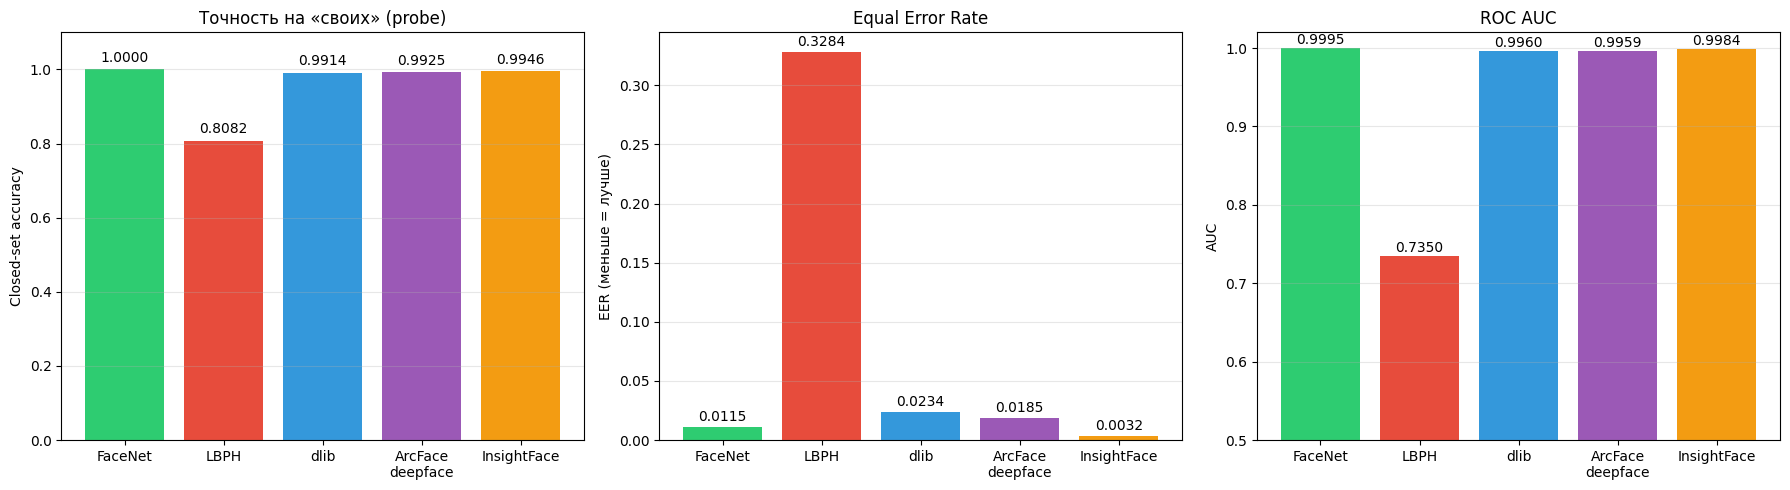


Архитектура                                Closed-set        EER        AUC
FaceNet (MTCNN+InceptionResnetV1)              1.0000     0.0115     0.9995
Haar + LBPH                                    0.8082     0.3284     0.7350
dlib HOG + ResNet-29                           0.9914     0.0234     0.9960
RetinaFace + ArcFace (deepface)                0.9925     0.0185     0.9959
SCRFD + ArcFace (InsightFace)                  0.9946     0.0032     0.9984


In [23]:
import matplotlib.pyplot as plt
import numpy as np

names = list(all_results.keys())
short_names = ["FaceNet", "LBPH", "dlib", "ArcFace\ndeepface", "InsightFace"]

closed = [all_results[n]["closed_set_accuracy"] for n in names]
eers = [all_results[n]["eer"] for n in names]
aucs = [all_results[n]["auc"] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Closed-set accuracy
bars = axes[0].bar(short_names, closed, color=["#2ecc71", "#e74c3c", "#3498db", "#9b59b6", "#f39c12"])
axes[0].set_ylabel("Closed-set accuracy")
axes[0].set_title("Точность на «своих» (probe)")
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis="y", alpha=0.3)
for bar, v in zip(bars, closed):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.4f}", ha="center", fontsize=10)

# EER (меньше = лучше)
bars = axes[1].bar(short_names, eers, color=["#2ecc71", "#e74c3c", "#3498db", "#9b59b6", "#f39c12"])
axes[1].set_ylabel("EER (меньше = лучше)")
axes[1].set_title("Equal Error Rate")
axes[1].grid(axis="y", alpha=0.3)
for bar, v in zip(bars, eers):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)

# AUC (больше = лучше)
bars = axes[2].bar(short_names, aucs, color=["#2ecc71", "#e74c3c", "#3498db", "#9b59b6", "#f39c12"])
axes[2].set_ylabel("AUC")
axes[2].set_title("ROC AUC")
axes[2].set_ylim(0.5, 1.02)
axes[2].grid(axis="y", alpha=0.3)
for bar, v in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{BENCH_DIR}/comparison_all.png", dpi=120, bbox_inches="tight")
plt.show()

# Таблица в консоли
print("\n" + "=" * 90)
print(f"{'Архитектура':<40} {'Closed-set':>12} {'EER':>10} {'AUC':>10}")
print("=" * 90)
for n, c, e, a in zip(names, closed, eers, aucs):
    print(f"{n:<40} {c:>12.4f} {e:>10.4f} {a:>10.4f}")
print("=" * 90)

In [27]:
import os
import cv2

VIDEO_DIR = "/content/drive/MyDrive/face_project/videos"
RAW_VIDEO = f"{VIDEO_DIR}/raw.mp4"

print("Файл существует:", os.path.exists(RAW_VIDEO))
print("Размер:", os.path.getsize(RAW_VIDEO) / 1024 / 1024, "МБ")

cap = cv2.VideoCapture(RAW_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Разрешение: {w}x{h}")
print(f"FPS: {fps}")
print(f"Кадров: {n_frames}")
print(f"Длительность: {n_frames / fps:.1f} сек")

Файл существует: True
Размер: 67.49104309082031 МБ
Разрешение: 1280x720
FPS: 29.97002997002997
Кадров: 11698
Длительность: 390.3 сек


In [28]:
VIDEO_DIR = "/content/drive/MyDrive/face_project/videos"
RAW_VIDEO = f"{VIDEO_DIR}/raw.mp4"
CLIP_VIDEO = f"{VIDEO_DIR}/clip.mp4"

# Узнаём длительность
cap = cv2.VideoCapture(RAW_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
total_sec = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) / fps
cap.release()

# Стартуем с середины
start_sec = max(0, int(total_sec / 2 - 30))
duration = 60

!ffmpeg -y -ss {start_sec} -i "{RAW_VIDEO}" -t {duration} -c copy "{CLIP_VIDEO}" -loglevel error

# Проверяем
cap = cv2.VideoCapture(CLIP_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"clip.mp4: {w}x{h}, {fps:.1f} FPS, {n} кадров, {n/fps:.1f} сек")

clip.mp4: 1280x720, 30.0 FPS, 1800 кадров, 60.1 сек


Найдено лиц: 4
  pred=unknown, sim=0.119, bbox=[901, 127, 1037, 306]
  pred=unknown, sim=0.120, bbox=[329, 123, 459, 297]
  pred=Colin_Powell, sim=0.687, bbox=[549, 210, 697, 405]
  pred=unknown, sim=0.151, bbox=[398, 50, 507, 219]


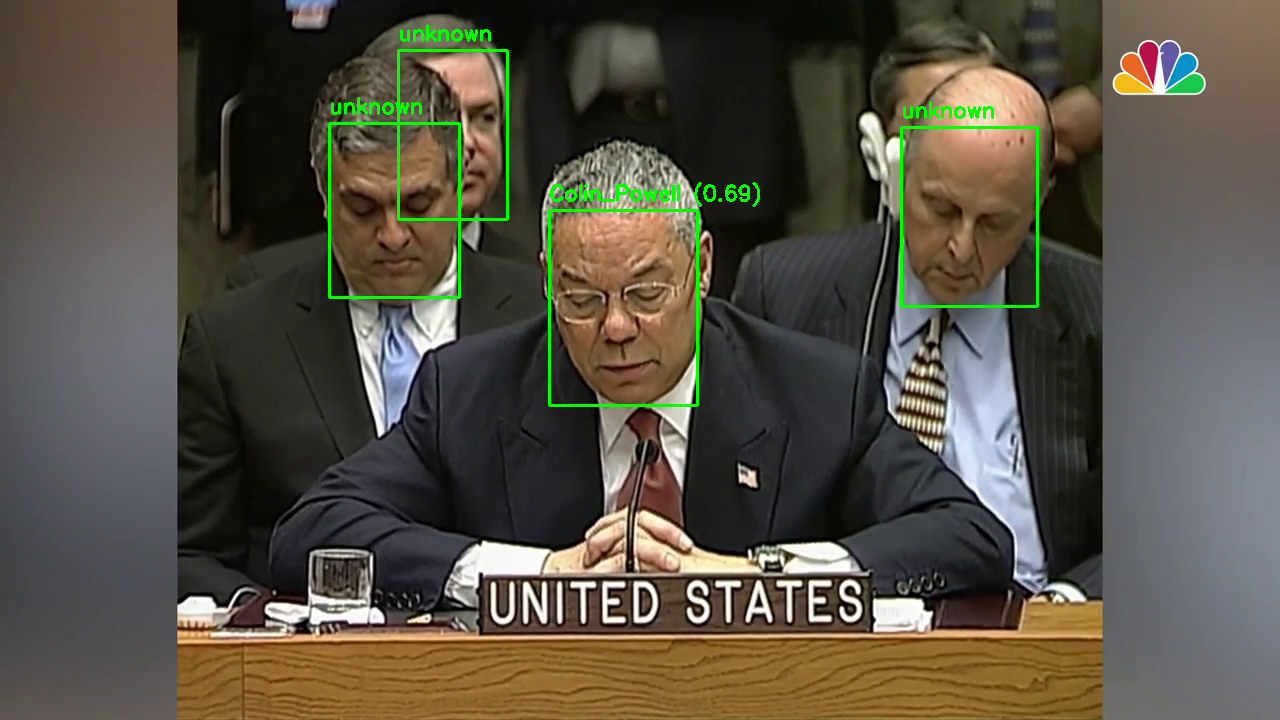

In [29]:
import numpy as np
from PIL import Image

gallery_insight = dict(np.load(f"{BENCH_DIR}/gallery_insightface.npz"))

cap = cv2.VideoCapture(CLIP_VIDEO)
mid = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, mid)
ret, frame = cap.read()
cap.release()

faces = insight_app.get(frame)
print(f"Найдено лиц: {len(faces)}")
for f in faces:
    emb = f.normed_embedding
    pred, sim, _ = identify_cosine(emb, gallery_insight, threshold=0.4088)
    print(f"  pred={pred}, sim={sim:.3f}, bbox={f.bbox.astype(int).tolist()}")

# Визуализируем
vis = frame.copy()
for f in faces:
    x1, y1, x2, y2 = f.bbox.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    pred, sim, _ = identify_cosine(f.normed_embedding, gallery_insight, threshold=0.4088)
    label = f"{pred} ({sim:.2f})" if pred != "unknown" else "unknown"
    cv2.putText(vis, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))

In [30]:
import os
import cv2
import numpy as np
import time
from collections import deque, Counter
from PIL import Image

VIDEO_DIR = "/content/drive/MyDrive/face_project/videos"
CLIP_VIDEO = f"{VIDEO_DIR}/clip.mp4"
RESULT_VIDEO = f"{VIDEO_DIR}/result.mp4"

# Загружаем эмбеддинги галереи
gallery_insight = dict(np.load(f"{BENCH_DIR}/gallery_insightface.npz"))

# ------------------------------------------------------------
# IoU-трекер
# ------------------------------------------------------------
def iou(box1, box2):
    """IoU двух боксов формата (x1, y1, x2, y2)."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0


class Track:
    def __init__(self, track_id, bbox, label, sim):
        self.id = track_id
        self.bbox = bbox
        self.history = deque(maxlen=15)  # история меток
        self.history.append((label, sim))
        self.missed = 0  # сколько кадров без детекции
        self.last_label = label
        self.last_sim = sim

    def update(self, bbox, label=None, sim=None):
        self.bbox = bbox
        if label is not None:
            self.history.append((label, sim))
            # Majority vote
            labels = [l for l, _ in self.history]
            self.last_label = Counter(labels).most_common(1)[0][0]
            # Средняя уверенность по тем кадрам, где метка совпала с majority
            sims = [s for l, s in self.history if l == self.last_label]
            self.last_sim = float(np.mean(sims)) if sims else sim
        self.missed = 0

    def predict_next(self):
        """Простое предсказание — оставляем bbox как есть."""
        return self.bbox


# ------------------------------------------------------------
# Основной цикл
# ------------------------------------------------------------
cap = cv2.VideoCapture(CLIP_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(RESULT_VIDEO, fourcc, fps, (W, H))

DETECT_EVERY = 5         # детекция каждые N кадров
IOU_THRESHOLD = 0.3      # порог сопоставления
MAX_MISSED = 10          # сколько кадров трек может жить без детекции
SIM_THRESHOLD = 0.4088   # EER-порог InsightFace

tracks = []
next_track_id = 0

print(f"Обрабатываем {n_frames} кадров ({n_frames/fps:.1f} сек)...")
t0 = time.time()

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # --- Детекция каждые N кадров ---
    if frame_idx % DETECT_EVERY == 0:
        faces = insight_app.get(frame)

        new_detections = []  # (bbox, label, sim)
        for f in faces:
            x1, y1, x2, y2 = f.bbox.astype(int)
            bbox = (x1, y1, x2, y2)

            # Идентификация
            pred, sim, _ = identify_cosine(f.normed_embedding, gallery_insight,
                                            threshold=SIM_THRESHOLD)
            new_detections.append((bbox, pred, sim))

        # --- Сопоставление с существующими треками ---
        used_track_ids = set()
        for bbox, label, sim in new_detections:
            best_iou = 0
            best_track = None
            for tr in tracks:
                if tr.id in used_track_ids:
                    continue
                i = iou(bbox, tr.bbox)
                if i > best_iou:
                    best_iou = i
                    best_track = tr

            if best_track is not None and best_iou > IOU_THRESHOLD:
                best_track.update(bbox, label, sim)
                used_track_ids.add(best_track.id)
            else:
                # Новый трек
                tr = Track(next_track_id, bbox, label, sim)
                tracks.append(tr)
                used_track_ids.add(next_track_id)
                next_track_id += 1

        # Увеличиваем missed у треков без детекции в этом кадре
        for tr in tracks:
            if tr.id not in used_track_ids:
                tr.missed += 1

        # Удаляем старые треки
        tracks = [tr for tr in tracks if tr.missed <= MAX_MISSED]

    # --- Рисуем на каждом кадре ---
    for tr in tracks:
        x1, y1, x2, y2 = tr.bbox
        # Цвет: зелёный для известных, серый для unknown
        color = (0, 220, 0) if tr.last_label != "unknown" else (140, 140, 140)

        # Рамка чуть расширяется с каждым кадром без детекции — эффект «уверенности»
        thickness = max(1, 3 - tr.missed // 4)

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)

        # Подпись
        if tr.last_label != "unknown":
            label = f"{tr.last_label} ({tr.last_sim:.2f})"
        else:
            label = "unknown"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 8, y1), color, -1)
        cv2.putText(frame, label, (x1 + 4, y1 - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    # Счётчик кадров
    cv2.putText(frame, f"Frame {frame_idx}/{n_frames}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    writer.write(frame)
    frame_idx += 1

    # Прогресс каждые 100 кадров
    if frame_idx % 100 == 0:
        elapsed = time.time() - t0
        eta = elapsed / frame_idx * (n_frames - frame_idx)
        print(f"  {frame_idx}/{n_frames} кадров, "
              f"прошло {elapsed:.1f}с, ETA {eta:.1f}с, "
              f"активных треков: {len(tracks)}")

cap.release()
writer.release()

print(f"\nГотово за {time.time()-t0:.1f} сек")
print(f"Результат: {RESULT_VIDEO}")
print(f"Размер: {os.path.getsize(RESULT_VIDEO)/1024/1024:.1f} МБ")

Обрабатываем 1800 кадров (60.1 сек)...
  100/1800 кадров, прошло 3.6с, ETA 61.1с, активных треков: 3
  200/1800 кадров, прошло 7.5с, ETA 60.3с, активных треков: 4
  300/1800 кадров, прошло 10.8с, ETA 54.2с, активных треков: 4
  400/1800 кадров, прошло 14.0с, ETA 48.9с, активных треков: 5
  500/1800 кадров, прошло 17.4с, ETA 45.2с, активных треков: 4
  600/1800 кадров, прошло 21.5с, ETA 43.0с, активных треков: 3
  700/1800 кадров, прошло 24.4с, ETA 38.3с, активных треков: 3
  800/1800 кадров, прошло 27.5с, ETA 34.4с, активных треков: 5
  900/1800 кадров, прошло 30.8с, ETA 30.8с, активных треков: 5
  1000/1800 кадров, прошло 35.6с, ETA 28.5с, активных треков: 4
  1100/1800 кадров, прошло 38.6с, ETA 24.6с, активных треков: 4
  1200/1800 кадров, прошло 41.6с, ETA 20.8с, активных треков: 4
  1300/1800 кадров, прошло 44.8с, ETA 17.2с, активных треков: 4
  1400/1800 кадров, прошло 49.1с, ETA 14.0с, активных треков: 4
  1500/1800 кадров, прошло 52.7с, ETA 10.5с, активных треков: 4
  1600/1800 

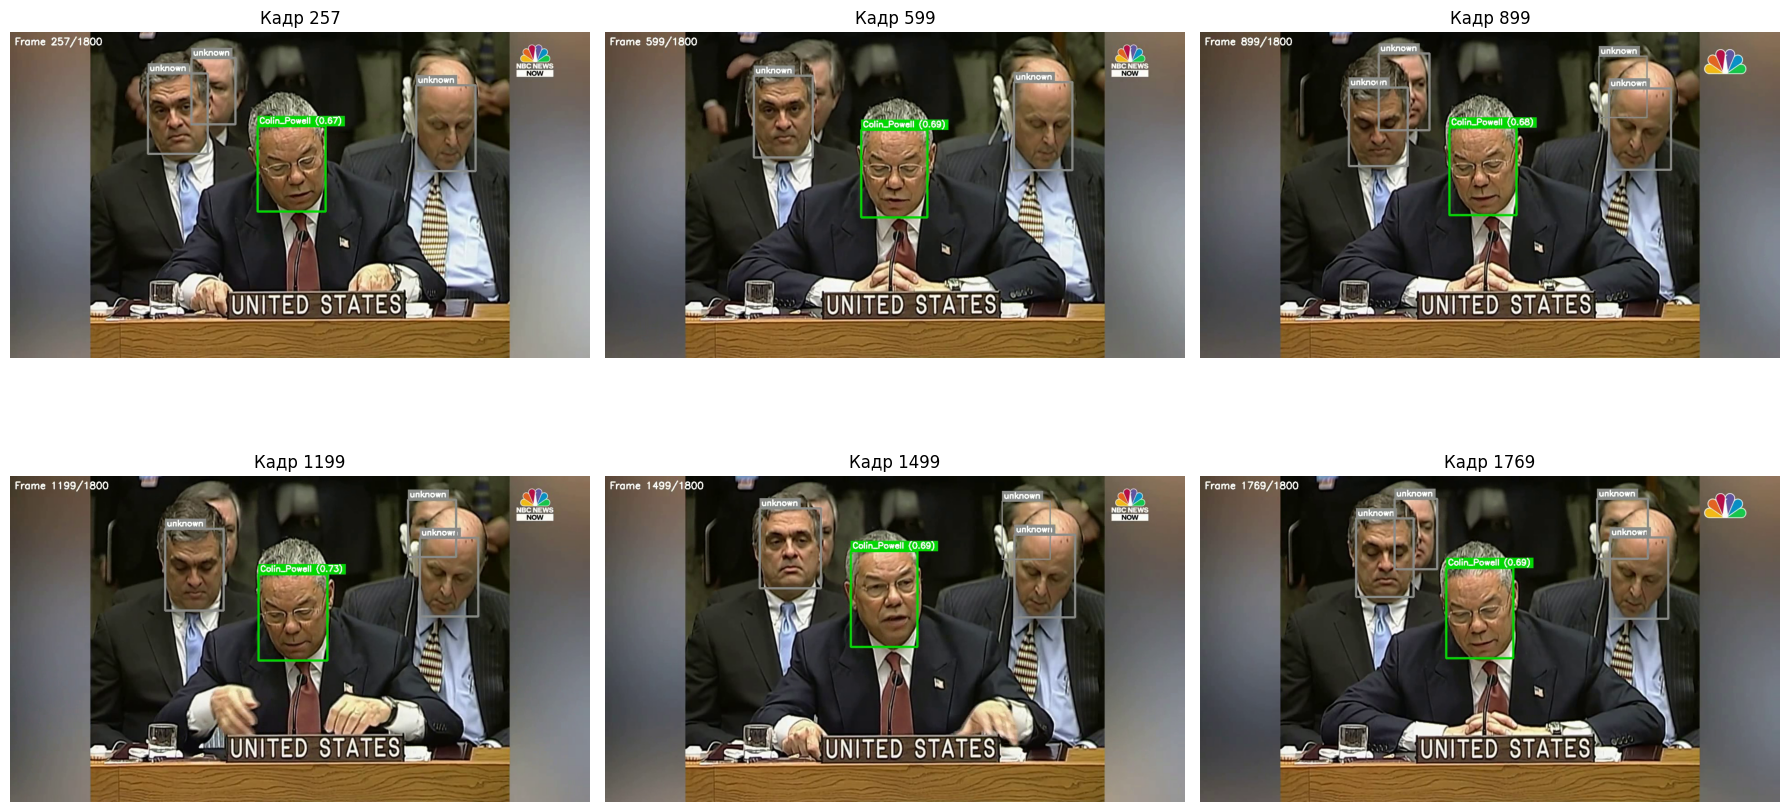

In [31]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image

RESULT_VIDEO = "/content/drive/MyDrive/face_project/videos/result.mp4"

cap = cv2.VideoCapture(RESULT_VIDEO)
n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Возьмём 6 кадров равномерно
frames_to_check = [n // 7, n // 3, n // 2, 2 * n // 3, 5 * n // 6, n - 30]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, idx in zip(axes.flat, frames_to_check):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Кадр {idx}")
        ax.axis("off")

cap.release()
plt.tight_layout()
plt.savefig(f"{BENCH_DIR}/video_samples.png", dpi=100, bbox_inches="tight")
plt.show()

In [32]:
import pickle
import os

BENCH_DIR = "/content/drive/MyDrive/face_project/benchmarks"

with open(f"{BENCH_DIR}/all_architectures.pkl", "rb") as f:
    all_results = pickle.load(f)

# Добавим скорость
speed_info = {
    "FaceNet (MTCNN+InceptionResnetV1)": "~13 it/s (CPU) / ~100 it/s (GPU)",
    "Haar + LBPH": "~90 it/s (CPU)",
    "dlib HOG + ResNet-29": "~2 it/s (CPU)",
    "RetinaFace + ArcFace (deepface)": "~4.5 it/s (GPU/CPU mixed)",
    "SCRFD + ArcFace (InsightFace)": "~15 it/s (GPU)",
}

print("=" * 110)
print(f"{'Архитектура':<40} {'Closed-set':>12} {'EER':>10} {'AUC':>10} {'Ложных':>10}")
print("=" * 110)
for name in all_results:
    r = all_results[name]
    n_false = sum(1 for s in r["hard_unknown_sims"] if s >= r.get("eer_threshold", 0.5))
    print(f"{name:<40} {r['closed_set_accuracy']:>12.4f} {r['eer']:>10.4f} "
          f"{r['auc']:>10.4f} {n_false:>10}")
print("=" * 110)

Архитектура                                Closed-set        EER        AUC     Ложных
FaceNet (MTCNN+InceptionResnetV1)              1.0000     0.0115     0.9995         21
Haar + LBPH                                    0.8082     0.3284     0.7350          0
dlib HOG + ResNet-29                           0.9914     0.0234     0.9960          6
RetinaFace + ArcFace (deepface)                0.9925     0.0185     0.9959          5
SCRFD + ArcFace (InsightFace)                  0.9946     0.0032     0.9984          1
